In [ ]:
pip install spacy matplotlib networkx

In [ ]:
!pip install spacy download en_core_web_sm

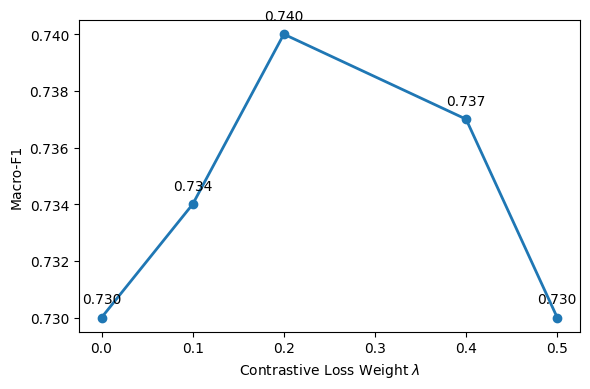

In [ ]:
import matplotlib.pyplot as plt

lam = [0.0, 0.1, 0.2, 0.4,0.5]
f1 = [0.730, 0.734, 0.740, 0.737,0.73]
a
plt.figure(figsize=(6,4))

plt.plot(lam, f1, marker='o', linewidth=2)

plt.xlabel(r'Contrastive Loss Weight $\lambda$')
plt.ylabel('Macro-F1')

for x, y in zip(lam, f1):
    plt.text(x, y + 0.0005, f'{y:.3f}', ha='center')

plt.tight_layout()

plt.savefig("lambda_ablation.png", dpi=300, bbox_inches='tight')

plt.show()

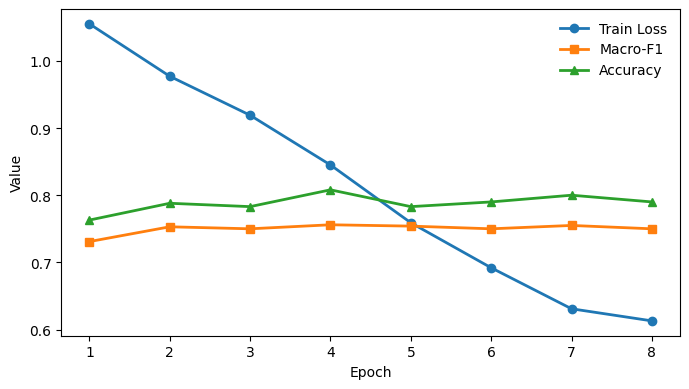

In [ ]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6,7,8]

train_loss = [1.055,0.977,0.919,0.845,0.759,0.692,0.631,0.613]
macro_f1 = [0.731,0.753,0.750,0.756,0.754,0.750,0.755,0.750]
accuracy = [0.763,0.788,0.783,0.808,0.783,0.790,0.800,0.790]

plt.figure(figsize=(7,4))

plt.plot(epochs, train_loss, marker='o', linewidth=2, label='Train Loss')
plt.plot(epochs, macro_f1, marker='s', linewidth=2, label='Macro-F1')
plt.plot(epochs, accuracy, marker='^', linewidth=2, label='Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Value')

plt.legend(frameon=False)

plt.tight_layout()

plt.show()

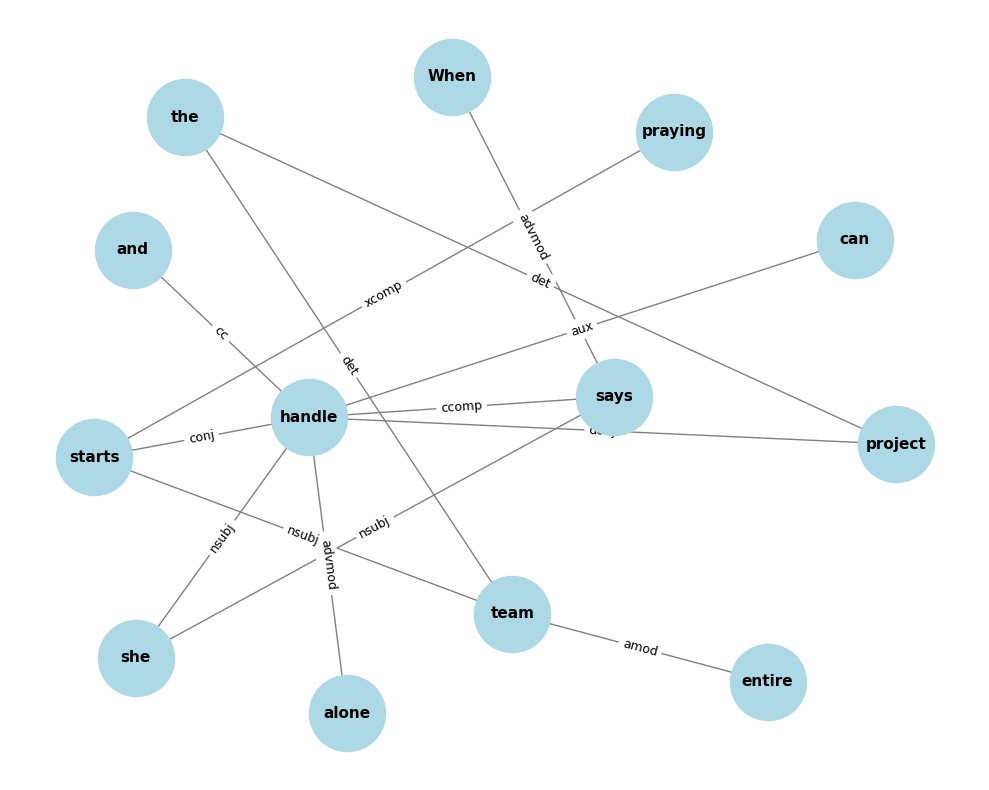

In [ ]:
# pip install spacy matplotlib networkx
# python -m spacy download en_core_web_sm

import spacy
import networkx as nx
import matplotlib.pyplot as plt

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Input sentence
text = "When she says she can handle the project alone and the entire team starts praying"

# Process text
doc = nlp(text)

# Create directed graph
G = nx.DiGraph()

# Add nodes and dependency edges
for token in doc:
    G.add_node(token.text)

    # Add edge from head -> dependent
    if token.head != token:
        G.add_edge(
            token.head.text,
            token.text,
            label=token.dep_
        )

# Layout
pos = nx.spring_layout(G, seed=42, k=1.8)

# Plot
plt.figure(figsize=(10, 8))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=3000,
    node_color="lightblue"
)

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    arrows=True,
    arrowsize=20
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    font_size=11,
    font_weight="bold"
)

# Dependency labels
edge_labels = nx.get_edge_attributes(G, 'label')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=9
)

# plt.title("Dependency Graph of Meme Text", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

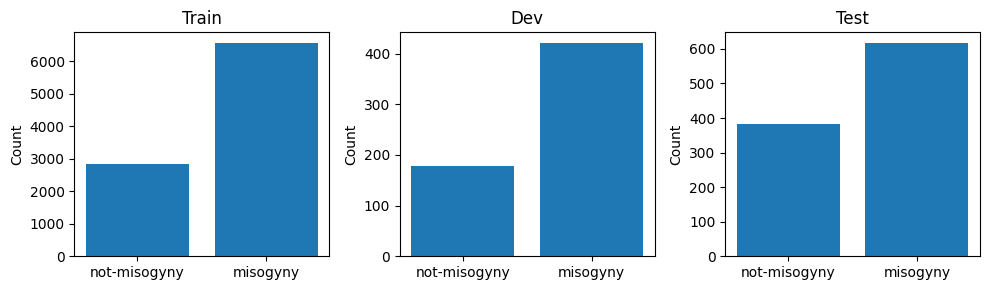

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
train = pd.read_csv("train.csv")
dev = pd.read_csv("dev.csv")
test = pd.read_csv("test.csv")

datasets = {
    "Train": train,
    "Dev": dev,
    "Test": test
}

labels = ["not-misogyny", "misogyny"]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, (name, df) in zip(axes, datasets.items()):

    counts = df["indian_labels"].value_counts().sort_index()

    ax.bar(labels, counts.values)

    ax.set_title(name)
    ax.set_ylabel("Count")

# plt.suptitle("Class Distribution Across Splits")
plt.tight_layout()
plt.show()

In [ ]:
texts = df["transcriptions"].tolist()
labels = df["indian_labels"].values


['misogyny' 'not-misogyny']


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/294 [00:00<?, ?it/s]

not-misogyny 6557
misogyny 2838


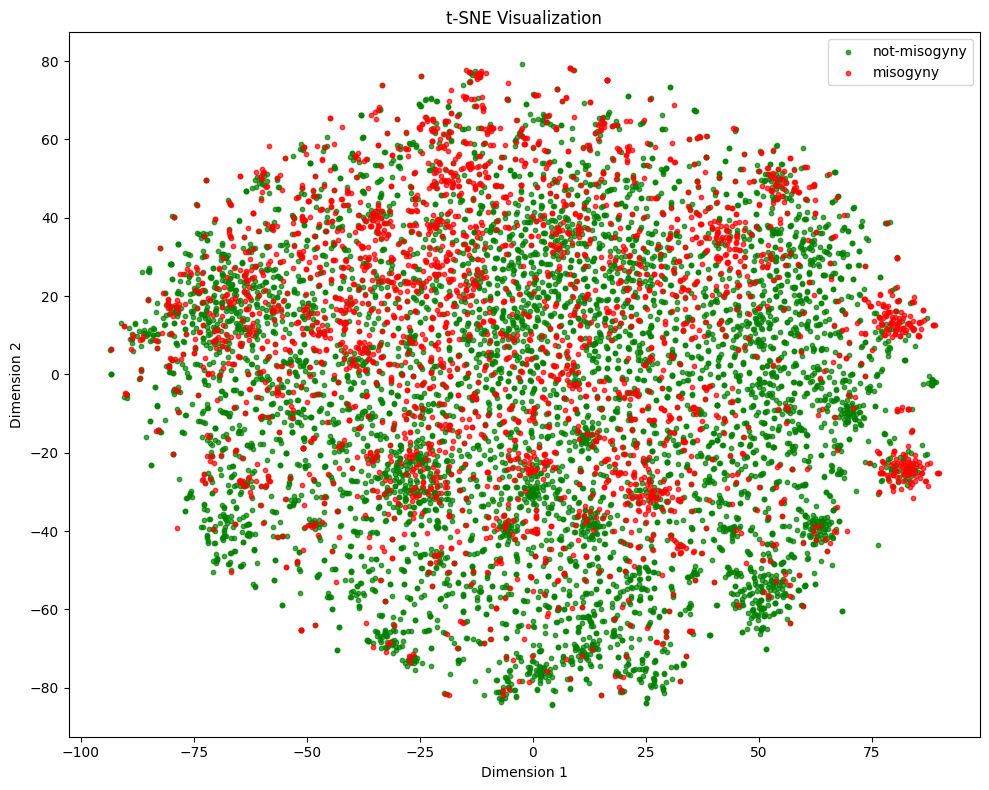

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

# Load dataset
df = pd.read_csv("train.csv")

# Remove missing rows
df = df.dropna(subset=["transcriptions", "indian_labels"])

texts = df["transcriptions"].tolist()
labels = df["indian_labels"].values

print(df["indian_labels"].unique())

# Embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    texts,
    show_progress_bar=True
)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca'
)

reduced = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))

colors = {
    "not-misogyny": "green",
    "misogyny": "red"
}

for label in colors.keys():

    idx = labels == label

    print(label, idx.sum())

    plt.scatter(
        reduced[idx, 0],
        reduced[idx, 1],
        s=10,
        alpha=0.7,
        c=colors[label],
        label=label
    )

plt.legend()
plt.title("t-SNE Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.show()

Unique labels: ['misogyny' 'not-misogyny']
Dataset size: 9395


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/294 [00:00<?, ?it/s]

Embedding shape: (9395, 384)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape: (9395, 2)
not-misogyny: 6557
misogyny: 2838


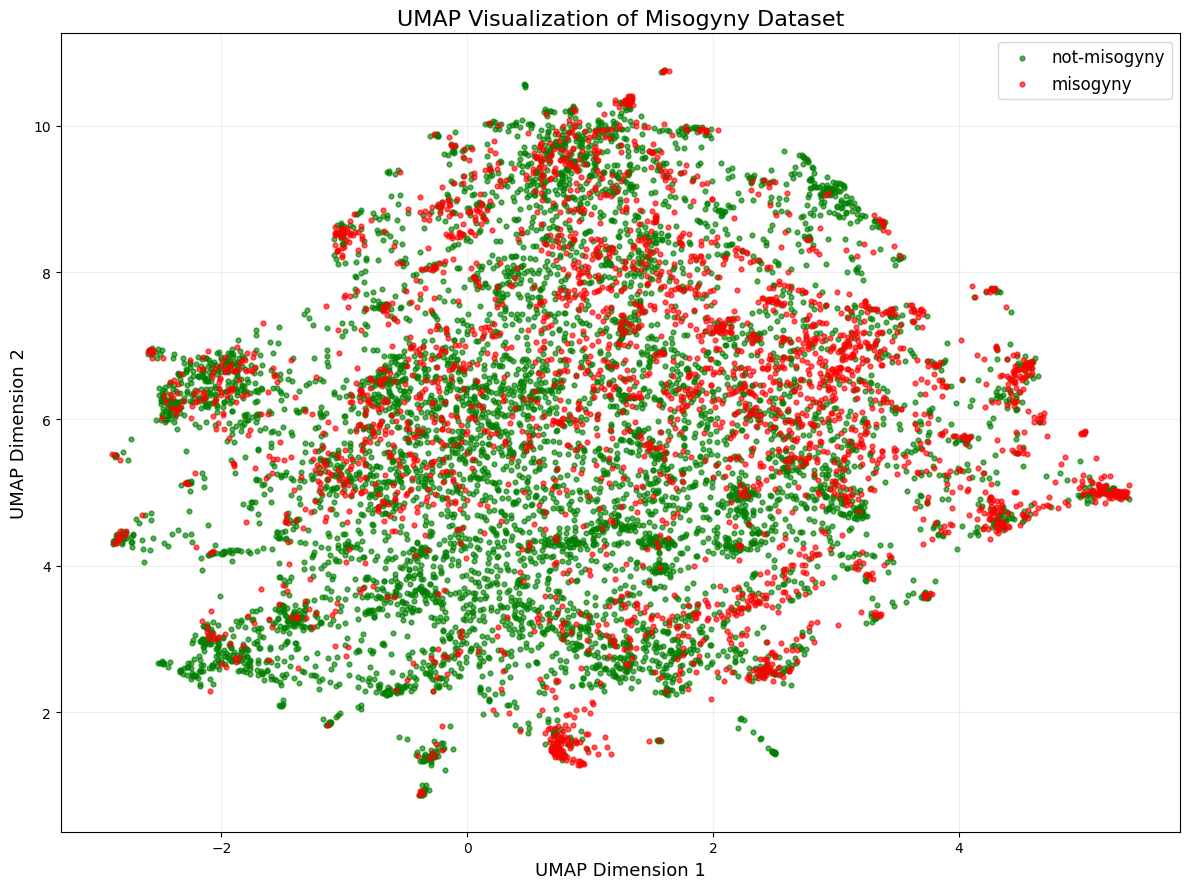

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap

from sentence_transformers import SentenceTransformer

# =========================
# Load dataset
# =========================

df = pd.read_csv("train.csv")

# Remove missing values
df = df.dropna(subset=["transcriptions", "indian_labels"])

# Optional:
# reduce dataset size if huge
# df = df.sample(5000, random_state=42)

texts = df["transcriptions"].astype(str).tolist()
labels = df["indian_labels"].astype(str).values

print("Unique labels:", df["indian_labels"].unique())
print("Dataset size:", len(df))

# =========================
# Generate embeddings
# =========================

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32
)

print("Embedding shape:", embeddings.shape)

# =========================
# UMAP reduction
# =========================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

reduced = reducer.fit_transform(embeddings)

print("Reduced shape:", reduced.shape)

# =========================
# Plot
# =========================

plt.figure(figsize=(8, 7))

colors = {
    "not-misogyny": "green",
    "misogyny": "red"
}

for label in colors.keys():

    idx = labels == label

    print(f"{label}: {idx.sum()}")

    plt.scatter(
        reduced[idx, 0],
        reduced[idx, 1],
        s=12,
        alpha=0.65,
        c=colors[label],
        label=label
    )

plt.legend(fontsize=12)

plt.title(
    "UMAP Visualization of Misogyny Dataset",
    fontsize=16
)

plt.xlabel("UMAP Dimension 1", fontsize=13)
plt.ylabel("UMAP Dimension 2", fontsize=13)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Total samples: 10995


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/344 [00:00<?, ?it/s]

Embedding shape: (10995, 384)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape: (10995, 2)
Train 9395
Dev 600
Test 1000


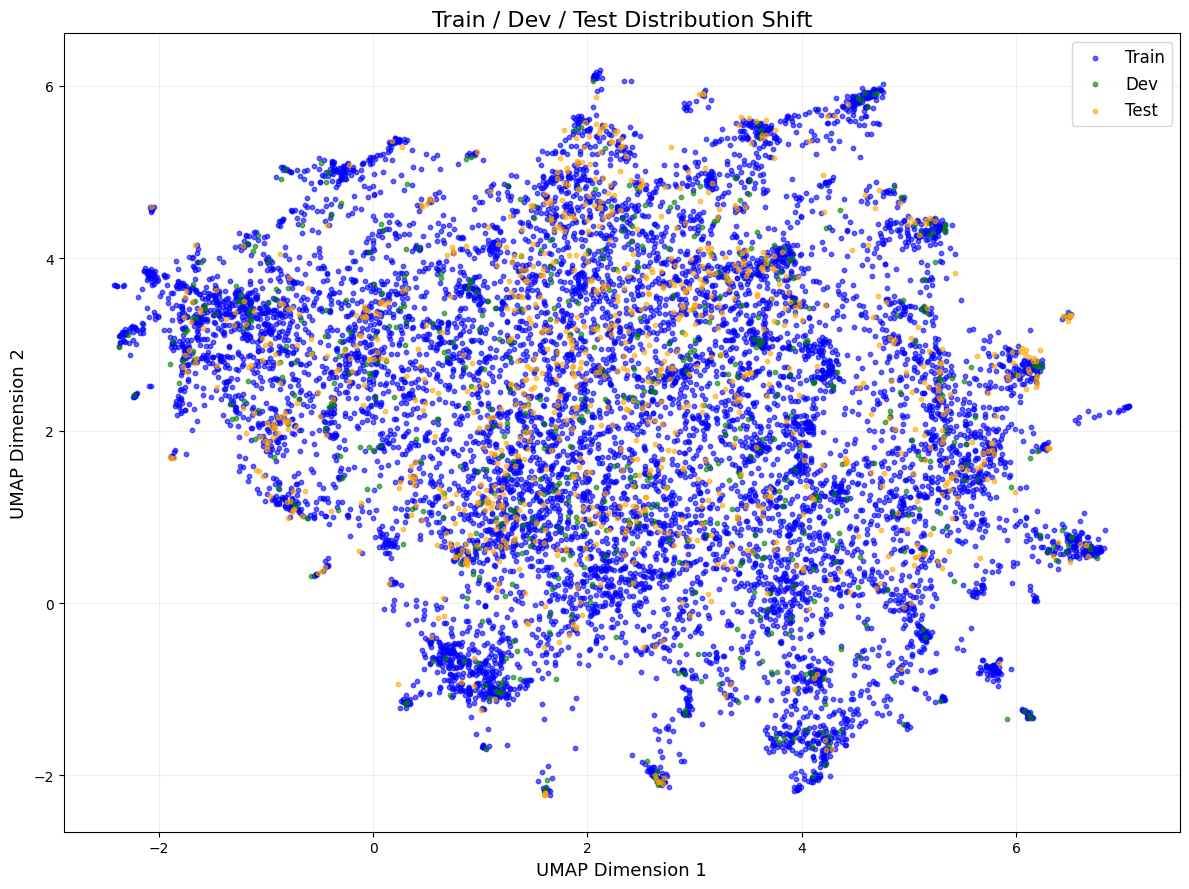

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sentence_transformers import SentenceTransformer
import numpy as np

# =========================
# Load datasets
# =========================

train = pd.read_csv("train.csv")
dev = pd.read_csv("dev.csv")
test = pd.read_csv("test.csv")

# Remove missing rows
train = train.dropna(subset=["transcriptions"])
dev = dev.dropna(subset=["transcriptions"])
test = test.dropna(subset=["transcriptions"])

# Optional:
# reduce size if huge
# train = train.sample(3000, random_state=42)
# dev = dev.sample(1000, random_state=42)
# test = test.sample(1000, random_state=42)

# =========================
# Combine all texts
# =========================

all_texts = (
    train["transcriptions"].astype(str).tolist() +
    dev["transcriptions"].astype(str).tolist() +
    test["transcriptions"].astype(str).tolist()
)

split_labels = (
    ["Train"] * len(train) +
    ["Dev"] * len(dev) +
    ["Test"] * len(test)
)

print("Total samples:", len(all_texts))

# =========================
# Generate embeddings
# =========================

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    all_texts,
    show_progress_bar=True,
    batch_size=32
)

print("Embedding shape:", embeddings.shape)

# =========================
# UMAP
# =========================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

reduced = reducer.fit_transform(embeddings)

print("Reduced shape:", reduced.shape)

# =========================
# Plot
# =========================

plt.figure(figsize=(12, 9))

colors = {
    "Train": "blue",
    "Dev": "green",
    "Test": "orange"
}

split_labels = np.array(split_labels)

for split in colors:

    idx = split_labels == split

    print(split, idx.sum())

    plt.scatter(
        reduced[idx, 0],
        reduced[idx, 1],
        s=10,
        alpha=0.6,
        c=colors[split],
        label=split
    )

plt.legend(fontsize=12)

plt.title(
    "Train / Dev / Test Distribution Shift",
    fontsize=16
)

plt.xlabel("UMAP Dimension 1", fontsize=13)
plt.ylabel("UMAP Dimension 2", fontsize=13)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Unique labels: ['misogyny' 'not-misogyny']
Dataset size: 9395


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/294 [00:00<?, ?it/s]

Embedding shape: (9395, 384)
Both Non-Misogyny 7274
Mixed Pair 6320
Both Misogyny 1406


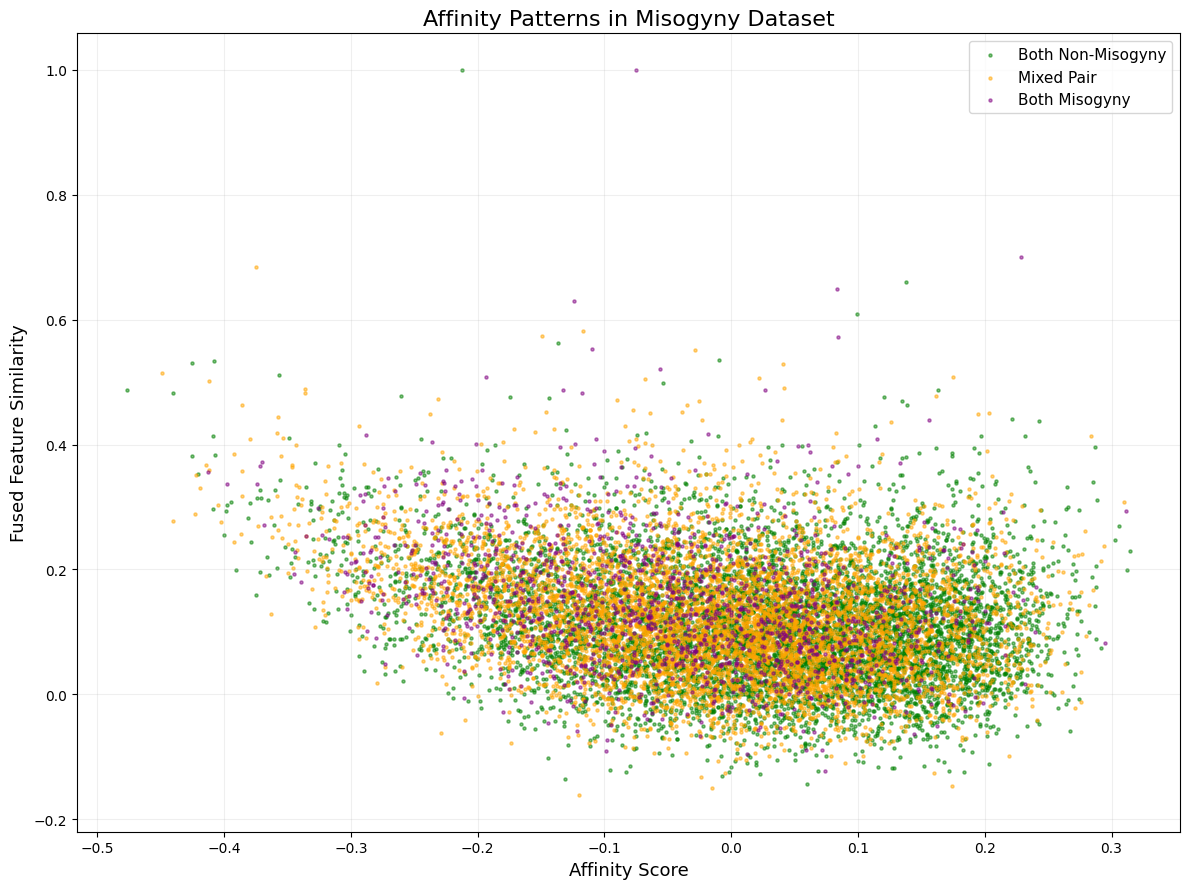

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# =========================
# Load dataset
# =========================

df = pd.read_csv("train.csv")

# Remove missing values
df = df.dropna(subset=["transcriptions", "indian_labels"])

# Optional:
# Reduce size if dataset is huge
# df = df.sample(5000, random_state=42)

texts = df["transcriptions"].astype(str).tolist()
labels = df["indian_labels"].astype(str).values

print("Unique labels:", np.unique(labels))
print("Dataset size:", len(df))

# =========================
# Generate embeddings
# =========================

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32
)

print("Embedding shape:", embeddings.shape)

# =========================
# Normalize embeddings
# =========================

embeddings = embeddings / np.linalg.norm(
    embeddings,
    axis=1,
    keepdims=True
)

# =========================
# PCA affinity score
# =========================

pca = PCA(n_components=1)

affinity_scores = pca.fit_transform(
    embeddings
).flatten()

# =========================
# Pair sampling
# =========================

x_vals = []
y_vals = []
pair_types = []

num_pairs = 15000

for _ in range(num_pairs):

    i, j = np.random.randint(
        0,
        len(labels),
        2
    )

    # Affinity score
    affinity = (
        affinity_scores[i] +
        affinity_scores[j]
    ) / 2

    # Cosine similarity
    similarity = cosine_similarity(
        embeddings[i].reshape(1, -1),
        embeddings[j].reshape(1, -1)
    )[0][0]

    # Pair category
    if (
        labels[i] == "not-misogyny"
        and
        labels[j] == "not-misogyny"
    ):

        pair_type = "Both Non-Misogyny"

    elif (
        labels[i] == "misogyny"
        and
        labels[j] == "misogyny"
    ):

        pair_type = "Both Misogyny"

    else:

        pair_type = "Mixed Pair"

    x_vals.append(affinity)
    y_vals.append(similarity)
    pair_types.append(pair_type)

# =========================
# Plot
# =========================

colors = {
    "Both Non-Misogyny": "green",
    "Mixed Pair": "orange",
    "Both Misogyny": "purple"
}

plt.figure(figsize=(12, 9))

pair_types = np.array(pair_types)

for ptype in colors:

    idx = pair_types == ptype

    print(ptype, idx.sum())

    plt.scatter(
        np.array(x_vals)[idx],
        np.array(y_vals)[idx],
        s=5,
        alpha=0.5,
        c=colors[ptype],
        label=ptype
    )

plt.xlabel(
    "Affinity Score",
    fontsize=13
)

plt.ylabel(
    "Fused Feature Similarity",
    fontsize=13
)

plt.title(
    "Affinity Patterns in Misogyny Dataset",
    fontsize=16
)

plt.legend(fontsize=11)

plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()